# 02 — Определение цвета автомобиля
### Практическая часть дипломной работы

**Задачи:**
1. EDA датасета — распределение классов, примеры изображений
2. Fine-tuning ResNet18 (9 классов цвета)
3. Оценка: Accuracy top-1/3, Confusion Matrix, F1 per class

**Классы:** black · white · silver · red · blue · yellow · green · brown · orange

**Датасет:** VCoR (Vehicle Color Recognition) — Kaggle, ~150 МБ

**Выход:** `color_resnet18.pth` → Google Drive

---
> **Предыдущий:** `01_detection.ipynb` | **Следующий:** `03_body_classifier.ipynb`

In [1]:
%%capture
!pip install -q torch torchvision Pillow matplotlib seaborn scikit-learn pandas tqdm


In [2]:
import json, time, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, top_k_accuracy_score
)
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
try:
    from google.colab import output as _colab_out; IN_COLAB = True
except ImportError:
    IN_COLAB = False

EPOCHS      = 20
BATCH_SIZE  = 32
LR          = 1e-3
UNFREEZE_AT = 5

COLOR_LABELS = ['black','white','silver','red','blue','yellow','green','brown','orange']

WORK_DIR   = Path('diploma_02_color')
DATA_DIR   = WORK_DIR / 'data' / 'color'
OUTPUT_DIR = WORK_DIR / 'output'
MODELS_DIR = WORK_DIR / 'models'
for d in [DATA_DIR, OUTPUT_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}  |  Epochs: {EPOCHS}')


Device: cuda  |  Epochs: 20


In [3]:
# ── Google Drive ──────────────────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_MODELS = Path('/content/drive/MyDrive/diploma/models')
else:
    DRIVE_MODELS = MODELS_DIR
DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = DRIVE_MODELS / 'color_resnet18.pth'
print(f'Модель: {MODEL_SAVE_PATH}')

Mounted at /content/drive
Модель: /content/drive/MyDrive/diploma/models/color_resnet18.pth


## 1. Подготовка датасета

### Ожидаемая структура:
```
diploma_02_color/data/color/
    train/  black/  white/  silver/  red/  blue/  yellow/  green/  brown/  orange/
    test/   ...
```

In [4]:
_vcor_train = DATA_DIR / 'train'
if not _vcor_train.exists():
    !pip install -q kaggle
    !kaggle datasets download -d landrykezebou/vcor-vehicle-color-recognition-dataset \
        -p {str(DATA_DIR)} --unzip
    print('Датасет VCoR скачан.')
else:
    print(f'Датасет VCoR уже скачан: {_vcor_train.parent}')

Dataset URL: https://www.kaggle.com/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset
License(s): copyright-authors
100% 574M/574M [00:04<00:00, 138MB/s]

Датасет VCoR скачан.


In [5]:
if (DATA_DIR / 'val').exists() and not (DATA_DIR / 'test').exists():
    (DATA_DIR / 'val').rename(DATA_DIR / 'test')

def count_classes(split_dir):
    return {c.name: len(list(c.glob('*.jpg')))
            for c in sorted(split_dir.iterdir()) if c.is_dir()}

train_counts = count_classes(DATA_DIR / 'train')
test_counts   = count_classes(DATA_DIR / 'test')
print(f'Train: {sum(train_counts.values())}  Test: {sum(test_counts.values())}')
print(train_counts)

Train: 7267  Test: 1556
{'beige': 421, 'black': 406, 'blue': 742, 'brown': 565, 'gold': 210, 'green': 563, 'grey': 428, 'orange': 534, 'pink': 483, 'purple': 536, 'red': 637, 'silver': 362, 'tan': 400, 'white': 403, 'yellow': 577}


## 2. EDA

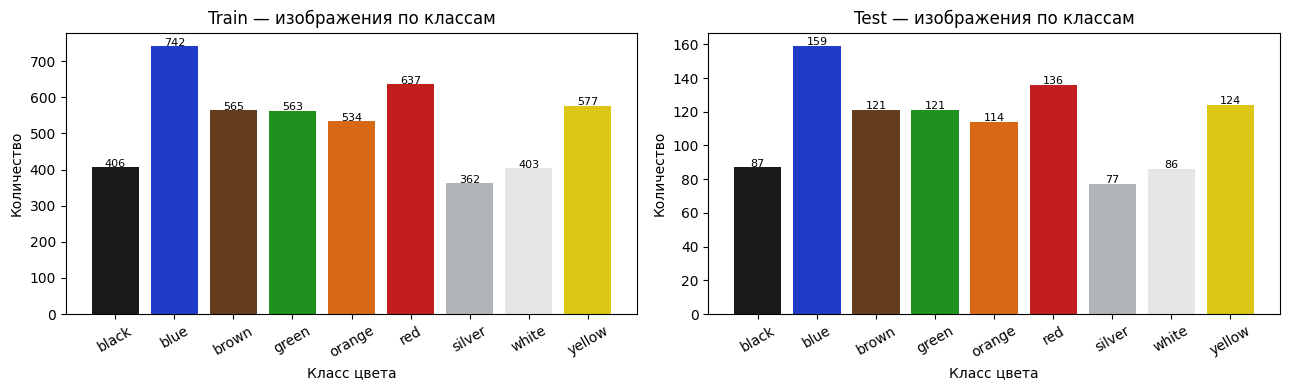

In [6]:
# ── Распределение классов ─────────────────────────────────────────────────────
_COLOR_RGB = {
    'black':(25,25,25), 'white':(230,230,230), 'silver':(175,180,185),
    'red':(195,30,30),  'blue':(30,60,200),    'yellow':(220,200,20),
    'green':(30,145,30),'brown':(100,60,30),   'orange':(215,105,20),
}

# оставляем только классы из COLOR_LABELS (датасет может содержать лишние папки)
train_counts = {k: v for k, v in train_counts.items() if k in COLOR_LABELS}
test_counts   = {k: v for k, v in test_counts.items()   if k in COLOR_LABELS}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for ax, counts, title in [(ax1, train_counts, 'Train'), (ax2, test_counts, 'Test')]:
    bars = ax.bar(counts.keys(), counts.values(),
                  color=[np.array(_COLOR_RGB[k])/255 for k in counts])
    ax.set_title(f'{title} — изображения по классам')
    ax.set_xlabel('Класс цвета'); ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, counts.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                str(v), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_class_distribution.png'), dpi=130, bbox_inches='tight')
plt.show()


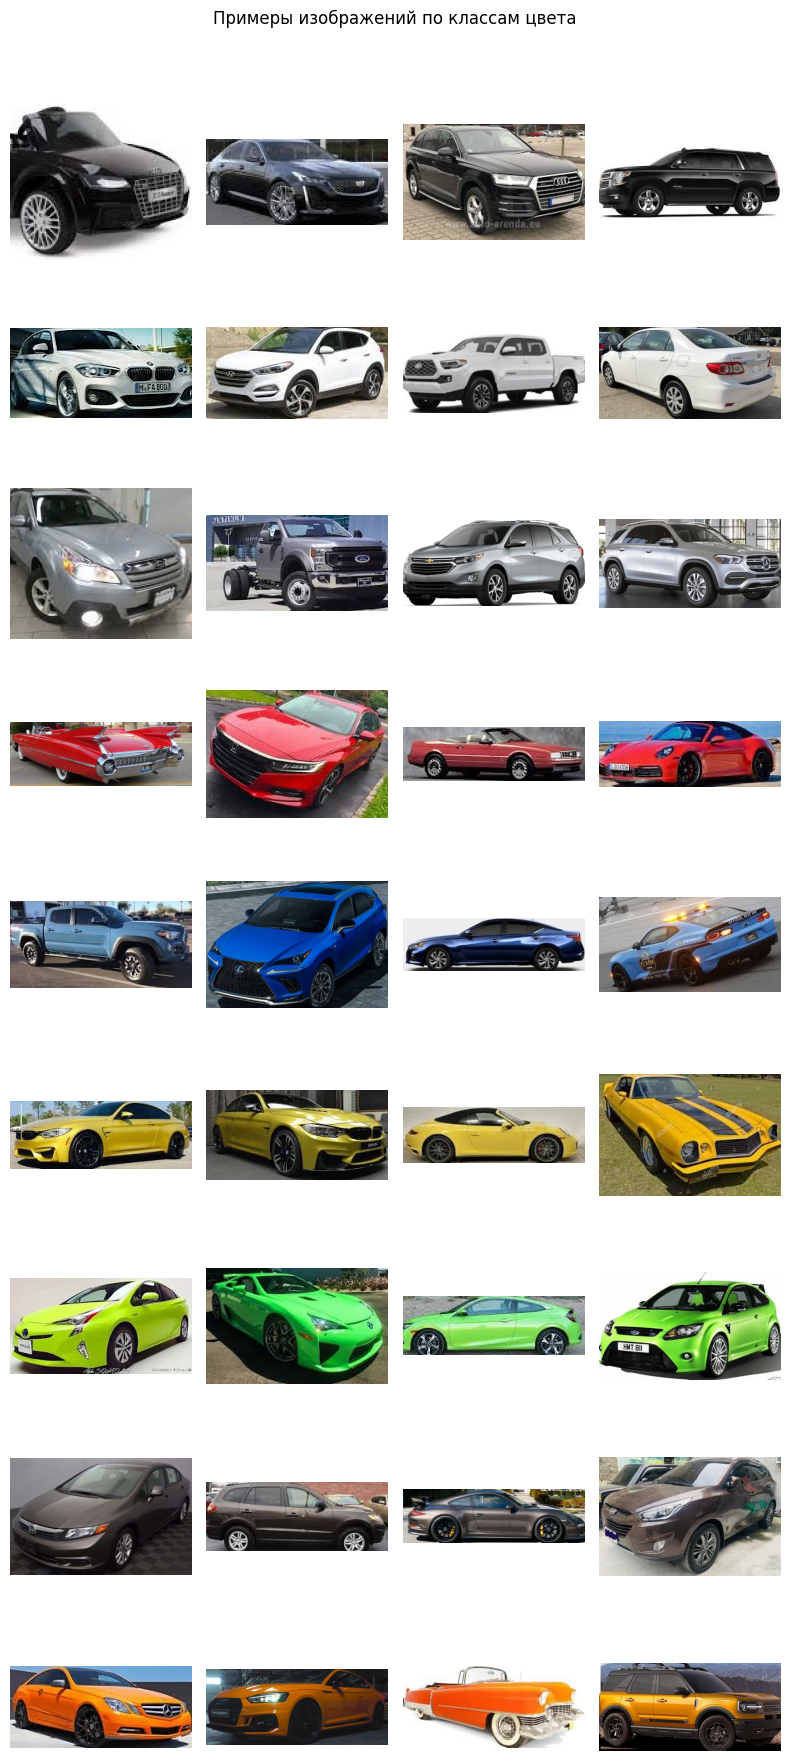

In [7]:
# ── Примеры изображений ───────────────────────────────────────────────────────
n_show = 4
fig, axes = plt.subplots(len(COLOR_LABELS), n_show,
                          figsize=(n_show*2, len(COLOR_LABELS)*2))
for row, label in enumerate(COLOR_LABELS):
    imgs = sorted((DATA_DIR / 'train' / label).glob('*.jpg'))[:n_show]
    for col, p in enumerate(imgs):
        axes[row][col].imshow(Image.open(p)); axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(label, fontsize=10, rotation=0,
                                       labelpad=45, va='center')
    for col in range(len(imgs), n_show): axes[row][col].axis('off')
plt.suptitle('Примеры изображений по классам цвета', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_samples.png'), dpi=120, bbox_inches='tight'); plt.show()

## 3. Fine-tuning ResNet18

**Двухфазное обучение:**
- **Фаза 1** (эпохи 1 → `UNFREEZE_AT`): backbone заморожен, только `fc`
- **Фаза 2** (эпохи `UNFREEZE_AT` → конец): весь backbone, LR × 0.1

In [8]:
TRAIN_TF = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
TEST_TF = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# передаём явный список классов — ImageFolder игнорирует лишние папки (beige и т.д.)
train_ds = ImageFolder(DATA_DIR / 'train', transform=TRAIN_TF)
train_ds.classes    = COLOR_LABELS
train_ds.class_to_idx = {c: i for i, c in enumerate(COLOR_LABELS)}
train_ds.samples    = [(p, train_ds.class_to_idx[Path(p).parent.name])
                       for p, _ in train_ds.samples
                       if Path(p).parent.name in COLOR_LABELS]
train_ds.targets    = [s[1] for s in train_ds.samples]

test_ds = ImageFolder(DATA_DIR / 'test', transform=TEST_TF)
test_ds.classes      = COLOR_LABELS
test_ds.class_to_idx = {c: i for i, c in enumerate(COLOR_LABELS)}
test_ds.samples      = [(p, test_ds.class_to_idx[Path(p).parent.name])
                       for p, _ in test_ds.samples
                       if Path(p).parent.name in COLOR_LABELS]
test_ds.targets      = [s[1] for s in test_ds.samples]

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'Классы: {train_ds.classes}')
print(f'Train: {len(train_ds)}  Test: {len(test_ds)}')

model = resnet18(weights=ResNet18_Weights.DEFAULT)
for p in model.parameters(): p.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, len(COLOR_LABELS))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)
print('Модель построена.')


Классы: ['black', 'white', 'silver', 'red', 'blue', 'yellow', 'green', 'brown', 'orange']
Train: 4789  Test: 1025
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 77.4MB/s]


Модель построена.


In [9]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if training: loss.backward(); optimizer.step()
            loss_sum += loss.item() * len(labels)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += len(labels)
    return loss_sum / total, correct / total


history, best_acc = [], 0.0
print(f'Обучение ResNet18 ({EPOCHS} эпох, device={DEVICE})')
print('─' * 65)
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    if epoch == UNFREEZE_AT:
        for p in model.parameters(): p.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=LR * 0.1)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)
        print(f'  [Epoch {epoch}] Backbone разморожен, lr={LR*0.1:.1e}')
    tl, ta = run_epoch(model, train_loader, criterion, optimizer)
    el, ea = run_epoch(model, test_loader,   criterion)
    scheduler.step()
    history.append({'epoch': epoch, 'tl': tl, 'ta': ta, 'el': el, 'ea': ea})
    print(f'  Epoch {epoch:2d}/{EPOCHS}  train_loss={tl:.4f}  test_acc={ea:.4f}')
    if ea > best_acc:
        best_acc = ea
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

print('─' * 65)
print(f'Best test_acc: {best_acc:.4f}  |  {time.time()-t0:.0f}s')
print(f'Модель → {MODEL_SAVE_PATH}')


Обучение ResNet18 (20 эпох, device=cuda)
─────────────────────────────────────────────────────────────────
  Epoch  1/20  train_loss=1.4863  test_acc=0.6907
  Epoch  2/20  train_loss=0.9096  test_acc=0.7210
  Epoch  3/20  train_loss=0.7744  test_acc=0.7698
  Epoch  4/20  train_loss=0.7120  test_acc=0.8020
  [Epoch 5] Backbone разморожен, lr=1.0e-04
  Epoch  5/20  train_loss=0.4889  test_acc=0.8605
  Epoch  6/20  train_loss=0.3214  test_acc=0.8722
  Epoch  7/20  train_loss=0.2444  test_acc=0.8761
  Epoch  8/20  train_loss=0.2191  test_acc=0.8878
  Epoch  9/20  train_loss=0.1663  test_acc=0.8898
  Epoch 10/20  train_loss=0.1136  test_acc=0.9141
  Epoch 11/20  train_loss=0.0851  test_acc=0.9073
  Epoch 12/20  train_loss=0.0747  test_acc=0.9141
  Epoch 13/20  train_loss=0.0670  test_acc=0.9132
  Epoch 14/20  train_loss=0.0585  test_acc=0.9073
  Epoch 15/20  train_loss=0.0503  test_acc=0.9220
  Epoch 16/20  train_loss=0.0479  test_acc=0.9122
  Epoch 17/20  train_loss=0.0406  test_acc=0.9132

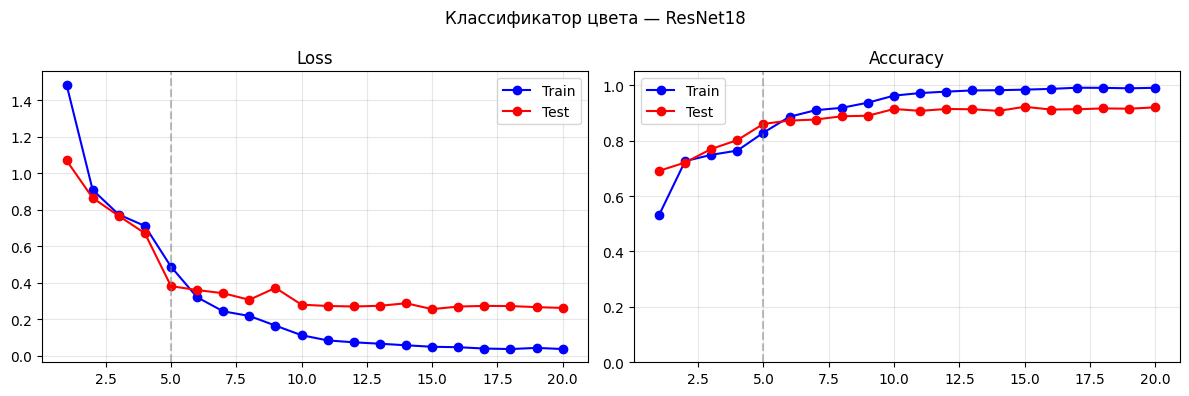

In [10]:
# ── Кривые обучения ───────────────────────────────────────────────────────────
ep = [h['epoch'] for h in history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ep, [h['tl'] for h in history], 'b-o', label='Train')
ax1.plot(ep, [h['el'] for h in history], 'r-o', label='Test')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.axvline(UNFREEZE_AT, color='gray', linestyle='--', alpha=0.5, label='unfreeze')
ax2.plot(ep, [h['ta'] for h in history], 'b-o', label='Train')
ax2.plot(ep, [h['ea'] for h in history], 'r-o', label='Test')
ax2.set_title('Accuracy'); ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(alpha=0.3)
ax2.axvline(UNFREEZE_AT, color='gray', linestyle='--', alpha=0.5)
plt.suptitle('Классификатор цвета — ResNet18')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'training_history.png'), dpi=130, bbox_inches='tight'); plt.show()

## 4. Оценка качества

In [11]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()

y_true, y_pred, y_proba = [], [], []
with torch.no_grad():
    for imgs, targets in test_loader:
        probs = torch.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
        y_proba.append(probs)
        y_pred.extend(probs.argmax(1).tolist())
        y_true.extend(targets.numpy().tolist())
y_proba = np.concatenate(y_proba)

acc1 = accuracy_score(y_true, y_pred)
acc3 = top_k_accuracy_score(y_true, y_proba, k=3)
rep  = classification_report(y_true, y_pred, target_names=COLOR_LABELS,
                              output_dict=True, zero_division=0)
print(f'Accuracy top-1: {acc1:.4f}')
print(f'Accuracy top-3: {acc3:.4f}')
print()
print(f'{"Класс":10s}  {"Precision":>9}  {"Recall":>6}  {"F1":>6}  {"N":>5}')
print('─' * 45)
for label in COLOR_LABELS:
    m = rep.get(label, {})
    print(f'{label:10s}  {m.get("precision",0):9.3f}  {m.get("recall",0):6.3f}  '
          f'{m.get("f1-score",0):6.3f}  {int(m.get("support",0)):5d}')

Accuracy top-1: 0.9220
Accuracy top-3: 0.9941

Класс       Precision  Recall      F1      N
─────────────────────────────────────────────
black           0.860   0.989   0.920     87
white           0.930   0.930   0.930     86
silver          0.910   0.792   0.847     77
red             0.921   0.941   0.931    136
blue            0.994   0.994   0.994    159
yellow          0.919   0.919   0.919    124
green           0.974   0.942   0.958    121
brown           0.930   0.884   0.907    121
orange          0.822   0.851   0.836    114


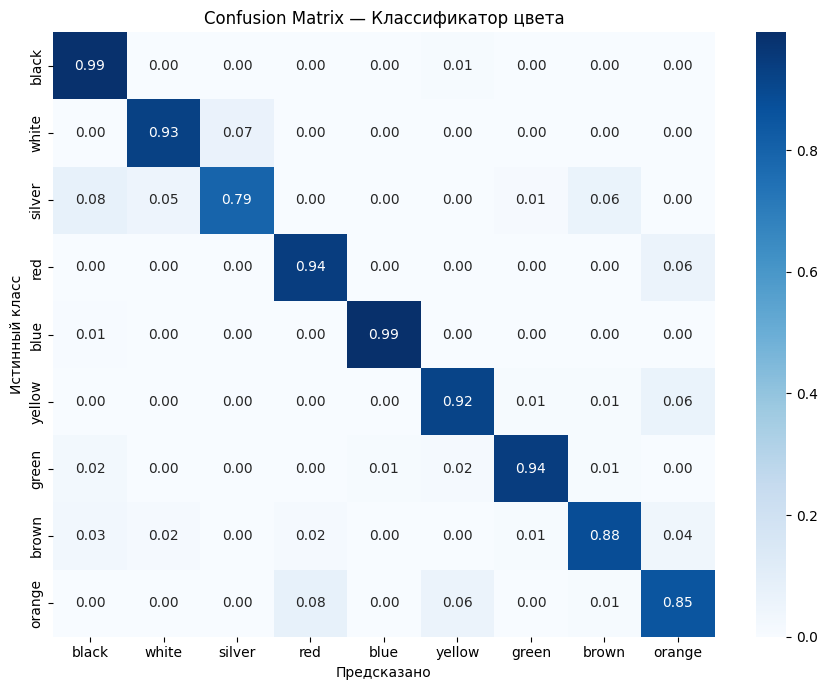

In [12]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / (cm.sum(1, keepdims=True) + 1e-9)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=COLOR_LABELS, yticklabels=COLOR_LABELS, ax=ax)
ax.set_xlabel('Предсказано'); ax.set_ylabel('Истинный класс')
ax.set_title('Confusion Matrix — Классификатор цвета')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'confusion_matrix.png'), dpi=150, bbox_inches='tight'); plt.show()

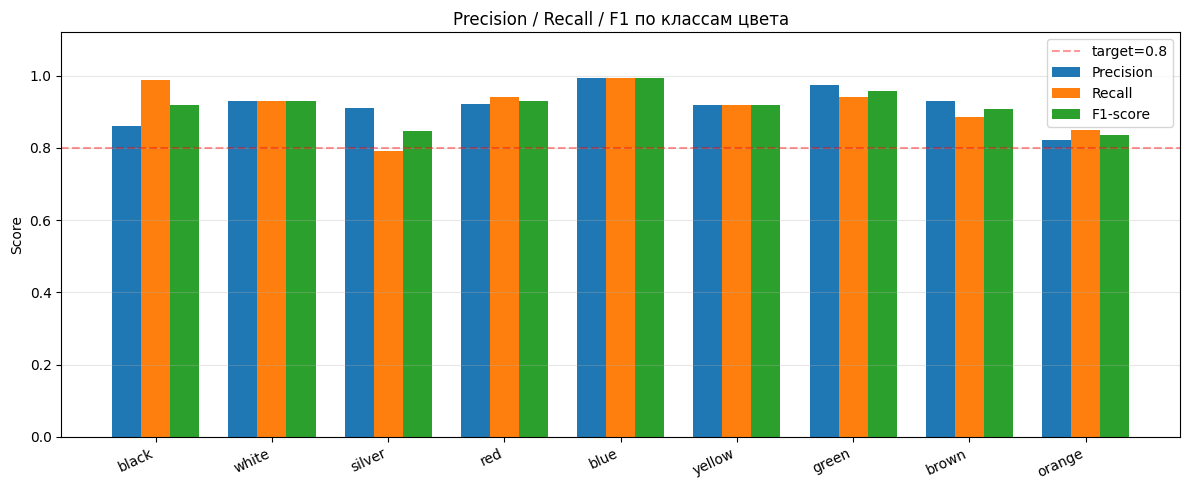

In [13]:
# ── Precision / Recall / F1 per class ────────────────────────────────────────
metrics_names = ['precision', 'recall', 'f1-score']
data = {m: [rep.get(l,{}).get(m,0) for l in COLOR_LABELS] for m in metrics_names}
x, w = np.arange(len(COLOR_LABELS)), 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i, (met, vals) in enumerate(data.items()):
    ax.bar(x + i*w, vals, w, label=met.capitalize())
ax.set_xticks(x + w); ax.set_xticklabels(COLOR_LABELS, rotation=25, ha='right')
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 по классам цвета')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.4, label='target=0.8')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'per_class_metrics.png'), dpi=130, bbox_inches='tight'); plt.show()

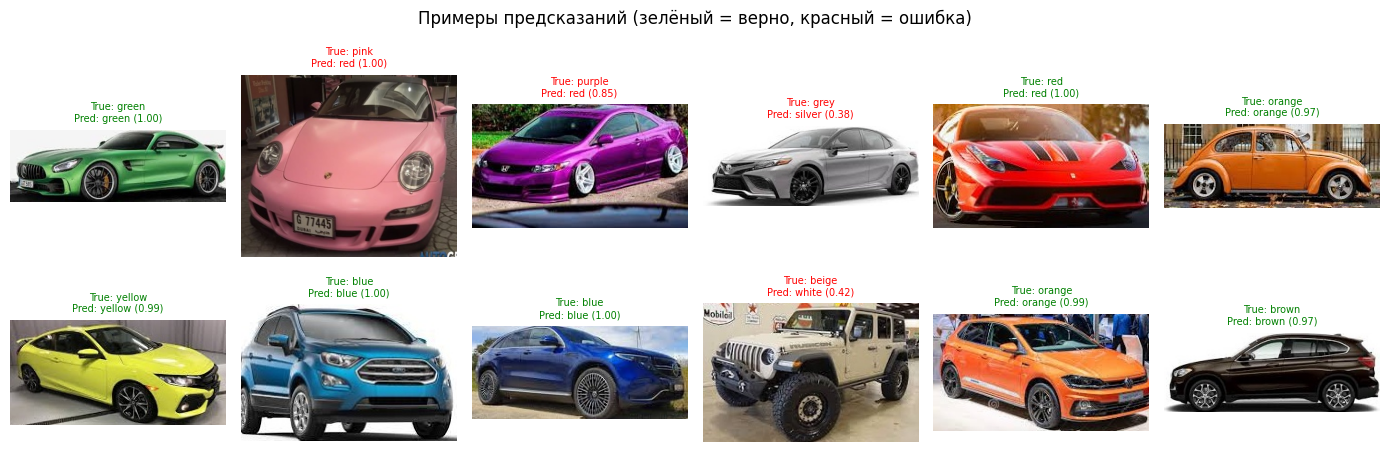

In [14]:
# ── Примеры предсказаний ──────────────────────────────────────────────────────
INF_TF = T.Compose([
    T.Resize((224,224)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
n_show = 12
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
all_test_imgs  = list((DATA_DIR / 'test').rglob('*.jpg'))
sample_paths  = np.random.choice(all_test_imgs, min(n_show, len(all_test_imgs)), replace=False)
model.eval()
with torch.no_grad():
    for i, p in enumerate(sample_paths):
        img_pil  = Image.open(p).convert('RGB')
        probs    = torch.softmax(model(INF_TF(img_pil).unsqueeze(0).to(DEVICE)),
                                 dim=1)[0].cpu().numpy()
        pred_idx = int(np.argmax(probs))
        true_lbl = p.parent.name
        pred_lbl = COLOR_LABELS[pred_idx]
        ax = axes[i//6][i%6]
        ax.imshow(img_pil); ax.axis('off')
        ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({probs[pred_idx]:.2f})',
                     fontsize=7, color='green' if true_lbl==pred_lbl else 'red')
plt.suptitle('Примеры предсказаний (зелёный = верно, красный = ошибка)')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'predictions_sample.png'), dpi=120, bbox_inches='tight'); plt.show()

In [15]:
# ── Итог ─────────────────────────────────────────────────────────────────────
results = {
    'task': 'color_classification', 'device': DEVICE,
    'epochs': EPOCHS, 'num_classes': len(COLOR_LABELS), 'classes': COLOR_LABELS,
    'accuracy_top1': round(acc1, 4), 'accuracy_top3': round(acc3, 4),
    'history': history,
}
with open(OUTPUT_DIR / 'results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print('═' * 55)
print(f'  Классификатор цвета — ИТОГ')
print(f'  Accuracy top-1:  {acc1:.4f}')
print(f'  Accuracy top-3:  {acc3:.4f}')
print(f'  Модель:          {MODEL_SAVE_PATH}')
print('═' * 55)

if IN_COLAB:
    import zipfile
    from google.colab import files
    with zipfile.ZipFile('results_02_color.zip', 'w') as zf:
        for p in OUTPUT_DIR.glob('*'): zf.write(p, p.name)
        zf.write(MODEL_SAVE_PATH, MODEL_SAVE_PATH.name)
    files.download('results_02_color.zip')

═══════════════════════════════════════════════════════
  Классификатор цвета — ИТОГ
  Accuracy top-1:  0.9220
  Accuracy top-3:  0.9941
  Модель:          /content/drive/MyDrive/diploma/models/color_resnet18.pth
═══════════════════════════════════════════════════════


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>